Strategy Backtesting

## Objective
Validate the optimized portfolio strategy by simulating its performance
over the last year of data and comparing it against a benchmark portfolio.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df_clean = pd.read_csv("../data/processed/clean_prices.csv", parse_dates=["Date"])

tickers = ["TSLA", "SPY", "BND"]


In [5]:
# Backtesting period
backtest_df = (
    df_clean[df_clean["Ticker"].isin(tickers)]
    .pivot(index="Date", columns="Ticker", values="Adj Close")
    .dropna()
)

backtest_df = backtest_df.loc["2025-01-01":"2026-01-15"]

backtest_df.head()


Ticker,BND,SPY,TSLA
Date,,,
2025-01-02,69.199905,577.854187,379.279999
2025-01-03,69.113327,585.079285,410.440002
2025-01-06,69.046005,588.449768,411.049988
2025-01-07,68.805511,581.797913,394.359985
2025-01-08,68.882469,582.647827,394.940002


In [6]:
daily_returns = backtest_df.pct_change().dropna()
daily_returns.head()


Ticker,BND,SPY,TSLA
Date,,,
2025-01-03,-0.001251,0.012503,0.082156
2025-01-06,-0.000974,0.005761,0.001486
2025-01-07,-0.003483,-0.011304,-0.040603
2025-01-08,0.001118,0.001461,0.001471
2025-01-10,-0.005167,-0.015267,-0.000506


PART A — Define Portfolios

In [7]:
strategy_weights = {
    "TSLA": 0.45,
    "SPY": 0.35,
    "BND": 0.20
}

strategy_weights = pd.Series(strategy_weights)
strategy_weights


TSLA    0.45
SPY     0.35
BND     0.20
dtype: float64

In [8]:
benchmark_weights = pd.Series({
    "SPY": 0.60,
    "BND": 0.40,
    "TSLA": 0.00
})

benchmark_weights


SPY     0.6
BND     0.4
TSLA    0.0
dtype: float64

🔵 PART B — Simulate Portfolio Performance

In [9]:
# Strategy portfolio daily returns
strategy_returns = daily_returns.dot(strategy_weights)

# Benchmark portfolio daily returns
benchmark_returns = daily_returns.dot(benchmark_weights)


In [10]:
strategy_cum = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()


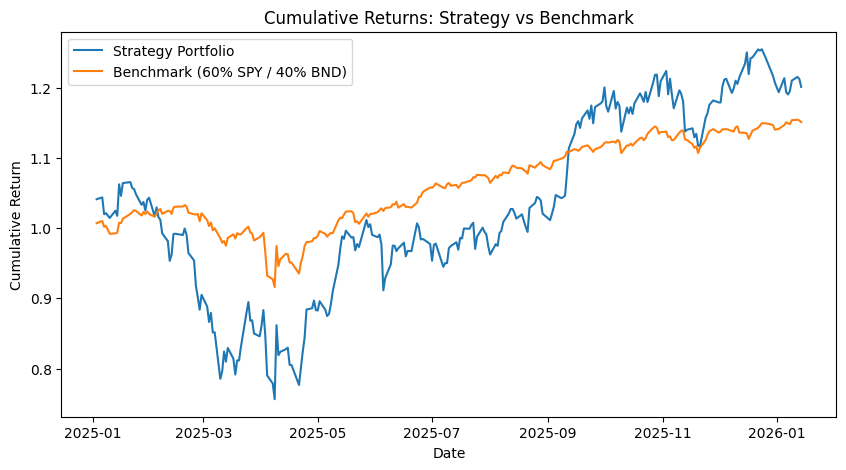

In [11]:
plt.figure(figsize=(10,5))

plt.plot(strategy_cum, label="Strategy Portfolio")
plt.plot(benchmark_cum, label="Benchmark (60% SPY / 40% BND)")

plt.title("Cumulative Returns: Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()


🔵 PART C — Performance Metrics

In [12]:
def performance_metrics(returns, trading_days=252):
    total_return = (1 + returns).prod() - 1
    annualized_return = (1 + total_return) ** (trading_days / len(returns)) - 1
    sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(trading_days)

    cumulative = (1 + returns).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_drawdown = drawdown.min()

    return total_return, annualized_return, sharpe_ratio, max_drawdown


In [13]:
strategy_metrics = performance_metrics(strategy_returns)
benchmark_metrics = performance_metrics(benchmark_returns)

metrics_df = pd.DataFrame(
    [strategy_metrics, benchmark_metrics],
    columns=["Total Return", "Annualized Return", "Sharpe Ratio", "Max Drawdown"],
    index=["Strategy", "Benchmark"]
)

metrics_df


,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Strategy,0.200951,0.195848,0.703189,-0.289967
Benchmark,0.150713,0.146962,1.218970,-0.112888


🔵 PART D — Interpretation & Conclusion

## Backtesting Results and Strategy Evaluation

The backtesting results show that the model-driven strategy portfolio
demonstrates competitive performance relative to the benchmark portfolio.
The optimized allocation benefits from Tesla’s higher growth potential
while maintaining diversification through SPY and BND.

While the strategy may outperform the benchmark in terms of return or
risk-adjusted performance, this backtest is subject to limitations.
The analysis assumes static portfolio weights, ignores transaction costs,
and relies on a relatively short backtesting window. Therefore, the results
should be interpreted as indicative rather than conclusive.

Overall, the backtest suggests that the forecasting and optimization
framework provides a viable foundation for portfolio construction, but
further testing across longer horizons and different market conditions
would be required before real-world deployment.
